# PyFC: Passing Non-Contiguous N-Dimensional Data

`compute_fc_intervals` accepts binned `data` of any N-dimensional shape (see
`pyfc_high_dimensional_tutorial.ipynb` for scaling to many *parameters* -- this notebook is
about the shape of the *data* itself). This notebook shows that this includes
**non-contiguous** arrays: views like `histogram.T`, or a slice taken with a step, that share
memory with another array but aren't laid out contiguously in it.

This case comes up naturally. Say you build a 2D histogram as `(E_bins, cos_theta_bins)`
because that's how your analysis code produces it, but you'd rather index it as
`(cos_theta_bins, E_bins)` when calling PyFC. The obvious thing to do is
`histogram.T` -- and that's exactly what we do below, with no extra `.copy()` required.

This notebook covers:
1. **Why this is a real edge case** -- a quick, self-contained look at the underlying
   `numpy`/`numba` behavior that non-contiguous arrays run into.
2. **PyFC handles it transparently** -- passing a transposed histogram straight into
   `compute_fc_intervals` and getting a correct result.
3. **Proof of correctness** -- not just "it doesn't crash": the result is compared against
   the same computation on an explicitly contiguous copy of the identical values.


In [1]:
%matplotlib inline

import numpy as np
from numba import njit

from pyfc import compute_fc_intervals

np.random.seed(20260727)

N_TOYS = 25   # Kept small so this notebook runs quickly; use >=500 for real analyses.
CORES = 2


def print_1d_bounds(results, n_params, cl_list):
    """Extract and print the 1D interval bounds directly from an in-memory `results` dict."""
    for p_idx in range(n_params):
        test_pts = results[f"1d_test_p{p_idx+1}"]
        print(f"  param{p_idx+1}:")
        for cl in cl_list:
            accepted = results[f"1d_accepted_p{p_idx+1}"][cl]
            accepted_pts = test_pts[accepted]
            if len(accepted_pts) == 0:
                print(f"    CL {cl}: no accepted points (empty interval)")
            else:
                print(f"    CL {cl}: [{accepted_pts.min():.4g}, {accepted_pts.max():.4g}]")


Numba detected: JIT compilation enabled for maximum speed.


## 1. Why this is a real edge case

Under the hood, PyFC's binned likelihood (`calc_nll` in `pyfc/binned.py`) flattens `data`,
`mu`, and `sigma2` to 1D with `.reshape(-1)` before summing over bins -- this is what lets
you pass a histogram of *any* shape and have it evaluated correctly regardless of how the
bins are laid out spatially. That flattening runs inside a `numba`-`@njit`-compiled function
for speed, and numba's `nopython`-mode `.reshape(-1)` has a real restriction that plain NumPy
does not: it only accepts **C-contiguous** input. A transposed array is a *view* -- same
memory, different strides -- so it fails:


In [2]:
@njit(fastmath=True, nogil=True)
def flatten_in_nopython_mode(arr):
    return arr.reshape(-1)


a = np.array([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
a_T = a.T  # transpose -> a non-contiguous view, not a copy

print("a_T.flags['C_CONTIGUOUS'] =", a_T.flags["C_CONTIGUOUS"])

try:
    flatten_in_nopython_mode(a_T)
except Exception as e:
    print(f"\n{type(e).__name__}: {e}")


a_T.flags['C_CONTIGUOUS'] = False



NotImplementedError: incompatible shape for array


That's a real `numba` restriction, not a PyFC bug -- but if PyFC's own `calc_nll` hit it
unguarded, passing a transposed histogram to `compute_fc_intervals` would crash with exactly
this confusing, low-level error instead of either working correctly or failing with a clear
message. Anyone who transposes, or otherwise non-trivially slices, their histogram before
calling PyFC would hit it, since the whole point of PyFC's N-D support is letting you lay out
bins however is natural for you.

## 2. PyFC handles it transparently

Internally, `calc_nll` (and the toy generators that also flatten a rate array) copy to a
contiguous layout first with `np.ascontiguousarray(...)` before calling `.reshape(-1)`.
That call is a **no-op** -- no copy, no cost -- when the input is already C-contiguous, which
is true for ordinary `np.array`/`np.zeros`/`np.random.poisson(...)`-constructed data (the vast
majority of real usage). Only genuinely non-contiguous input pays for a copy, and that input
would otherwise have crashed anyway. In other words: you never need to think about this --
just pass your data however is natural, transposed or not.

Below, `observed_counts` is built as `(E_bins, cos_theta_bins)` and then transposed to
`(cos_theta_bins, E_bins)` -- a non-contiguous view -- exactly as it would be passed straight
into `compute_fc_intervals`.


observed_costheta_E.shape = (4, 3)
observed_costheta_E.flags['C_CONTIGUOUS'] = False

Running compute_fc_intervals directly on the transposed (non-contiguous) histogram...



--- 1D interval bounds (from the non-contiguous transposed histogram) ---
  param1:
    CL 0.68: [0.7143, 0.9714]
    CL 0.9: [0.4571, 0.9714]
  param2:
    CL 0.68: [0.9714, 0.9714]
    CL 0.9: [0.9714, 0.9714]

Global best fit: [0.73206964 0.94342335]


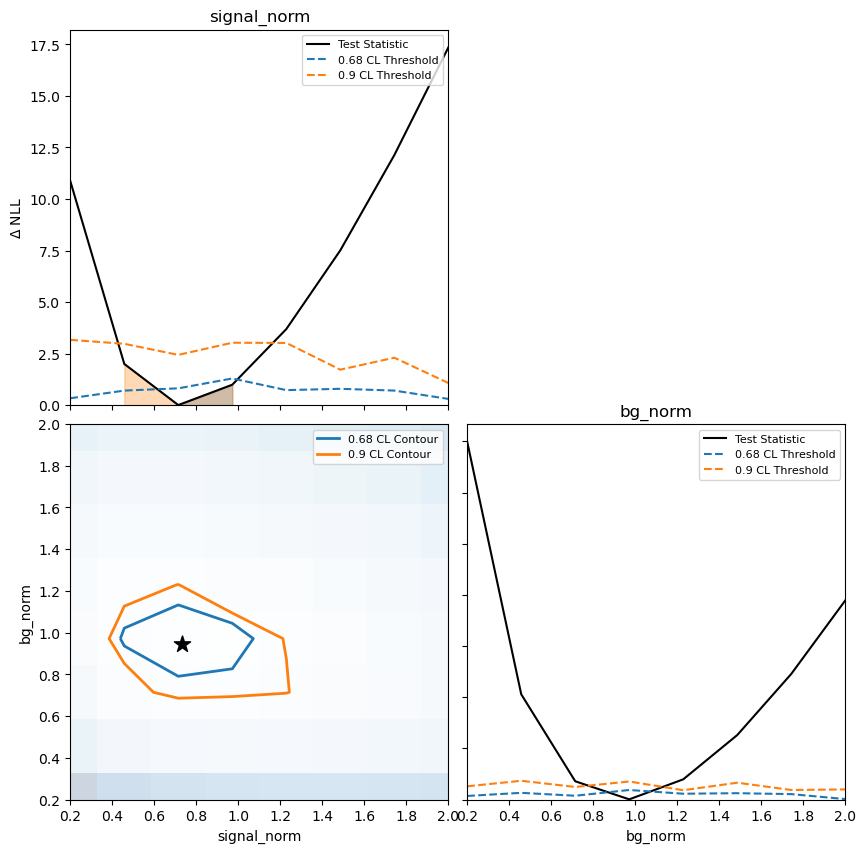

In [3]:
# A small 2-parameter binned model over an (E_bins=3, cos_theta_bins=4) histogram.
S_template_E_costheta = np.array([
    [0.1, 0.5, 2.0, 5.0],
    [0.2, 0.8, 2.5, 4.0],
    [0.3, 1.0, 1.5, 3.0],
])  # shape (E_bins=3, cos_theta_bins=4) as produced upstream
B_template_E_costheta = np.array([
    [15.0, 5.0, 1.0, 0.1],
    [12.0, 6.0, 1.5, 0.2],
    [10.0, 7.0, 2.0, 0.3],
])

np.random.seed(1)
observed_E_costheta = np.random.poisson(
    1.0 * S_template_E_costheta + 1.0 * B_template_E_costheta
).astype(float)

# Reindex to (cos_theta_bins, E_bins) via a plain transpose -- a non-contiguous VIEW,
# not a copy -- exactly the natural thing to do, and exactly what we pass to PyFC.
observed_costheta_E = observed_E_costheta.T
S_template = S_template_E_costheta.T
B_template = B_template_E_costheta.T
ZERO_SUMW2 = np.zeros_like(S_template)

print("observed_costheta_E.shape =", observed_costheta_E.shape)
print("observed_costheta_E.flags['C_CONTIGUOUS'] =", observed_costheta_E.flags["C_CONTIGUOUS"])


@njit(fastmath=True, nogil=True)
def compute_rates(params, S_sumw2, B_sumw2):
    """ params = (signal_norm, bg_norm). """
    mu = params[0] * S_template + params[1] * B_template
    sigma2 = (params[0]**2) * S_sumw2 + (params[1]**2) * B_sumw2
    return mu, sigma2


grids = [np.linspace(0.2, 2.0, 8), np.linspace(0.2, 2.0, 8)]

print("\nRunning compute_fc_intervals directly on the transposed (non-contiguous) histogram...")
results_noncontig, _ = compute_fc_intervals(
    data=observed_costheta_E,
    grids=grids,
    compute_rates_func=compute_rates,
    likelihood_type="binned",
    S_sumw2=ZERO_SUMW2, B_sumw2=ZERO_SUMW2,
    cl=[0.68, 0.90],
    n_toys=N_TOYS,
    num_cores=CORES,
    verbose=0,
    sparsify_grid=False,
    param_names=["signal_norm", "bg_norm"],
    save_directory="non_contiguous_output/transposed",
)

print("\n--- 1D interval bounds (from the non-contiguous transposed histogram) ---")
print_1d_bounds(results_noncontig, n_params=2, cl_list=[0.68, 0.90])
print("\nGlobal best fit:", results_noncontig["best_fit"])


## 3. Proof of correctness

Running without an exception is necessary but not sufficient -- it should also give the
*same* answer as the same physical model evaluated on an explicitly contiguous copy of the
identical values. We rerun with `.copy()`'d (contiguous) versions of every array above and
compare the unconditional NLL at the observed data, which is deterministic given fixed data
and `compute_rates_func`.


observed_costheta_E_contig.flags['C_CONTIGUOUS'] = True

Running the same model on a contiguous copy of the identical values...



data_uncond_nll (non-contiguous input) = -147.7817918193
data_uncond_nll (contiguous copy)       = -147.7817918193

Match confirmed: the non-contiguous input gives the identical result.


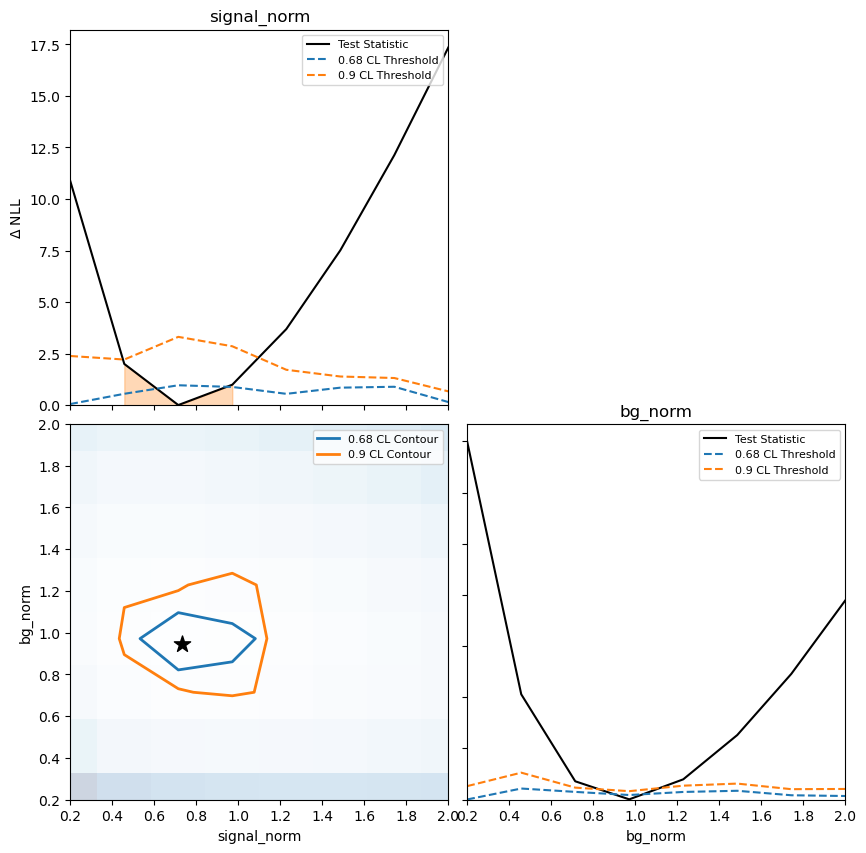

In [4]:
observed_costheta_E_contig = observed_costheta_E.copy()
S_template_contig = S_template.copy()
B_template_contig = B_template.copy()
ZERO_SUMW2_contig = np.zeros_like(S_template_contig)

print("observed_costheta_E_contig.flags['C_CONTIGUOUS'] =", observed_costheta_E_contig.flags["C_CONTIGUOUS"])


@njit(fastmath=True, nogil=True)
def compute_rates_contig(params, S_sumw2, B_sumw2):
    mu = params[0] * S_template_contig + params[1] * B_template_contig
    sigma2 = (params[0]**2) * S_sumw2 + (params[1]**2) * B_sumw2
    return mu, sigma2


print("\nRunning the same model on a contiguous copy of the identical values...")
results_contig, _ = compute_fc_intervals(
    data=observed_costheta_E_contig,
    grids=grids,
    compute_rates_func=compute_rates_contig,
    likelihood_type="binned",
    S_sumw2=ZERO_SUMW2_contig, B_sumw2=ZERO_SUMW2_contig,
    cl=[0.68, 0.90],
    n_toys=N_TOYS,
    num_cores=CORES,
    verbose=0,
    sparsify_grid=False,
    param_names=["signal_norm", "bg_norm"],
    save_directory="non_contiguous_output/contiguous",
)

print(f"\ndata_uncond_nll (non-contiguous input) = {results_noncontig['data_uncond_nll']:.10f}")
print(f"data_uncond_nll (contiguous copy)       = {results_contig['data_uncond_nll']:.10f}")
assert np.isclose(results_noncontig["data_uncond_nll"], results_contig["data_uncond_nll"])
print("\nMatch confirmed: the non-contiguous input gives the identical result.")


## Next steps

* **`pyfc_quickstart_tutorial.ipynb`** -- the runnable counterpart to the README Quick Start
  Guide, for binned and unbinned models from scratch.
* **`pyfc_high_dimensional_tutorial.ipynb`** -- scaling to many free *parameters* (a
  different axis from this notebook's focus on the shape of the *data*).
* **`pyfc_algorithmic_features_tutorial.ipynb`** -- the `sparsify_grid`, `smooth_1d`/
  `smooth_2d`, and `use_finite_mc_correction_binned` knobs.
